# Transistor sizing using $g_m/I_D$ method
Lookup Tables (LUTs) can be generating by running the following commands from the repository root
```bash
cd lib/gmid/src
PYTHONPATH=. python ../../ihp_analog_academy/modules/module_0_foundations/sg13_nmos_lv.py 
PYTHONPATH=. python ../../ihp_analog_academy/modules/module_0_foundations/sg13_pmos_lv.py 
cp sg13_nmos_lv_LUT.npz ../../../resources
cp sg13_pmos_lv_LUT.npz ../../../resources
```
This will create the files `sg13_nmos_lv_LUT.npz` and `sg13_pmos_lv_LUT.npz` under `lib/gmid/src` and copy them under the `resources` directory of the repository for easier access from this notebook.

This notebook aims to size three transistors for a cascode CG stage
<p align="center">
<img src="imag/Cascoded_CG.png">
</p>

# Using Boris Murmann's LUTs and `pygmid`
Lookup tables are generated in SPICE by sweeping four variables:
* Channel length $L$.
* Gate-Source voltage $V_{GS}$.
* Drain-Source voltage $V_{DS}$.
* Body-Source voltage $V_{SB}$.

The transistor used in the SPICE simulations has 5 gate fingers and a total width $W$ of $10\,\mu \mathrm{m}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pygmid import Lookup as lk

# Load the pregenerated lookup file from the submodule
lut = lk('../lib/gmid_book/starter_files_open_source_tools/ihp-sg13g2/simulation/sg13_lv_nmos.mat')

In [2]:
# Extract sweeped variables from the LUT
L1 = min(lut['L'])  # 0.13 micron
vgs = lut['VGS']
vds = lut['VDS']
vsb = lut['VSB']

## Sizing $M_1$
In order to correctly size $M_1$ we must first select a bias current $I_{D0}$ that will yield around $80$ to $90\%$ of the saturated value of $g_m$. To better visualize the relationship between $g_m$ and $I_D$ we can plot the curve for the minimum channel length that the technology allows ($0.13\,\mu\mathrm{m}$ for SG13G2):

Max gm: 0.004065
gm_0: 0.003252
Corresponding ID_0: 0.0007301755244755245
gm_0/ID_0: 4.4537236472502535


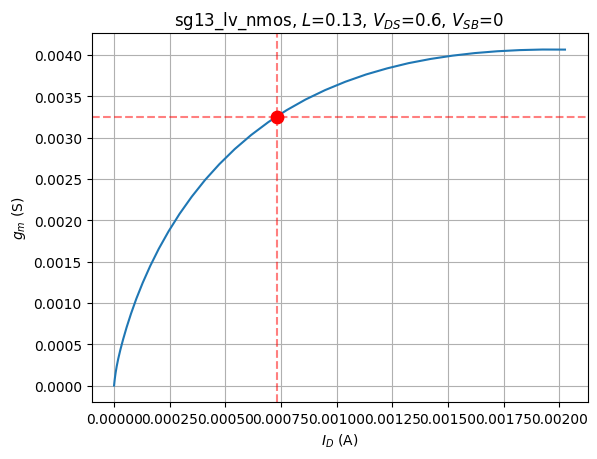

In [3]:
VDS1=np.max(vds)/2  # Leave sufficient headroom 
VSB1=0              # Body shorted to source

# Get the corresponding rows from the LUT
gm = lut.lookup('GM', L=L1, VDS=VDS1, VSB=VSB1)
Id = lut.lookup('ID', L=L1, VDS=VDS1, VSB=VSB1)

# Select the value that corresponds to 80% of saturated gm
gm_0 = 0.8 * np.max(gm)
ID_0 = np.interp(gm_0, gm, Id)  # Obtain I_D from selected gm
gm_id1 = gm_0 / ID_0

print(f"Max gm: {np.max(gm)}")
print(f"gm_0: {gm_0}")
print(f"Corresponding ID_0: {ID_0}")
print(f"gm_0/ID_0: {gm_id1}")

# Plot gm vs Id, mark selected point
fig, ax1 = plt.subplots()
ax1.grid()
ax1.set_xlabel('$I_{D}$ (A)')
ax1.set_ylabel('$g_m$ (S)')
ax1.plot(Id, gm)
ax1.scatter(ID_0, gm_0, color='r', s=80, zorder=3, label="0.8·gm_max")
ax1.axhline(gm_0, color='r', linestyle='--', alpha=0.5)
ax1.axvline(ID_0, color='r', linestyle='--', alpha=0.5)
plt.title("sg13_lv_nmos"+', $L$='+str(L1)+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.show()


Now that we have the $g_m/I_D$ ratio for $M_1$, we can obtain the necessary $I_D$ current to achieve $g_m = 1/50\,\Omega$:

In [4]:
gm1 = 1/ 50
I_D1  = gm1 / gm_id1
print(f"I_D for M1 is {I_D1} A")

I_D for M1 is 0.0044906243817682935 A


We can also directly obtain the corresponding width $W$:

In [5]:
gm_w = lut.look_up('GM_W', GM_ID=gm_id1)
W1 = gm1 / gm_w
print(f"W for M1 is {W1} microns")

W for M1 is 30.710795773798058 microns


If we keep the gate finger width at $2\,\mu\mathrm{m}$ as in the LUT, we can directly obtain the number of gate fingers for $M_1$:

In [6]:
nf1 = np.max([np.round(W1/2), 1])
print(f"Number of gate fingers for N1 is {nf1}")

Number of gate fingers for N1 is 15.0


With all geometric parameters chosen, we can now obtain the electrical characteristics of the transistor. We start by visualizing the $V_{GS}$ voltage that corresponds to the selected $g_m/I_D$ for $M_1$

VGS_1 = 0.8618787416762518
f_T1 = 58.49011400411106 GHz


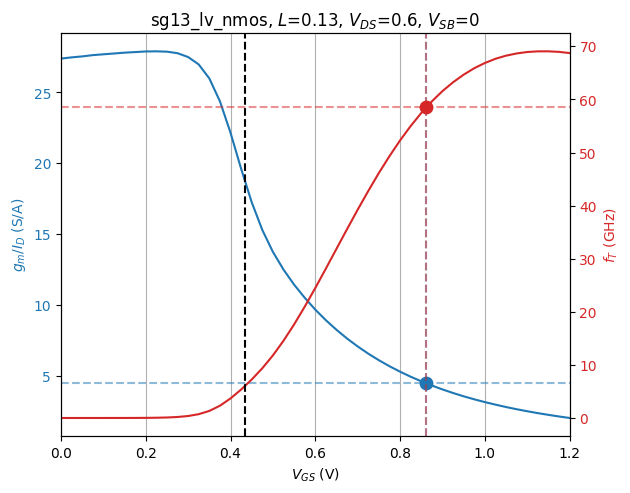

In [7]:
gm_id = lut.lookup('GM_ID', L=L1, VDS=VDS1, VSB=VSB1)    # Get the gm/ID values from the LUT
V_GS1 = np.interp(gm_id1, np.sort(gm_id), np.flip(vgs)) # Interpolate to obtain V_GS1

ft = lut.lookup('GM_CGG', L=L1, VDS=VDS1, VSB=VSB1)/2/np.pi
f_T1 = np.interp(V_GS1, vgs, ft)
print(f"VGS_1 = {V_GS1}")
print(f"f_T1 = {f_T1/1e9} GHz")


vt = lut.lookup('VT', L=L1, VGS=V_GS1, VDS=VDS1, VSB=VSB1)


# plot gm/ID and fT versus gate bias

fig, ax1 = plt.subplots()
ax1.grid(axis='x')
ax1.set_xlabel('$V_{GS}$ (V)')
color = 'tab:blue'
ax1.set_ylabel('$g_m/I_D$ (S/A)', color=color)
ax1.plot(vgs, gm_id, color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.scatter(V_GS1, gm_id1, color=color, s=80, zorder=3, label="0.8·gm_max")
ax1.axvline(V_GS1, color=color, linestyle='--', alpha=0.5)
ax1.axhline(gm_id1, color=color, linestyle='--', alpha=0.5)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('$f_T$ (GHz)', color=color)
ax2.plot(vgs, ft/1e9, color=color)
ax2.scatter(V_GS1, f_T1/1e9, color=color, s=80, zorder=3, label="0.8·gm_max")
ax2.axvline(V_GS1, color=color, linestyle='--', alpha=0.5)
ax2.axhline(f_T1/1e9, color=color, linestyle='--', alpha=0.5)
ax2.tick_params(axis='y', labelcolor=color)
fig.tight_layout()
plt.title('sg13_lv_nmos, $L$='+str(L1)+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.xlim(0, np.max(vgs))
plt.axvline(x=vt, color='k', linestyle='--')
plt.show()

From the graph we can see that the $V_{GS}$ voltage for $M_1$ is around $0.8\,\mathrm{V}$, above threshold voltage (black dashed line), and the transit frequency $f_T$ is very close to $60\,\mathrm{GHz}$. Note that $V_{GS}$ varies by $\pm100\dots200\,\mathrm{mV}$ over process and temperature so this graph shouldn't be taken too seriously.

Drain-Source saturation voltage $V_{Dsat}$ is well approximated by $2/(g_m/I_D)$:

In [8]:
V_Dsat1 = 2 / (gm_id1)
print(f"V_Dsat for M1 is {V_Dsat1} V")

V_Dsat for M1 is 0.4490624381768294 V


Finally, we obtain the capacitances from the LUT

In [9]:
CGS_W = lut.look_up('CGS_W', L=L1, VGS=V_GS1, VDS=VDS1, VSB=VSB1)
CSS_W = lut.look_up('CSS_W', L=L1, VGS=V_GS1, VDS=VDS1, VSB=VSB1)
CDD_W = lut.look_up('CDD_W', L=L1, VGS=V_GS1, VDS=VDS1, VSB=VSB1)
C_GS1 = CGS_W * W1
C_SS1 = CSS_W * W1
C_DD1 = CDD_W * W1
print(f"Gate-Source capacitance for M1 is {C_GS1/1e-15} fF")
print(f"Total Source capacitance for M1 is {C_SS1/1e-15} fF")
print(f"Total Drain capacitance for M1 is {C_DD1/1e-15} fF")

Gate-Source capacitance for M1 is 34.23259764670623 fF
Total Source capacitance for M1 is 41.001696553774565 fF
Total Drain capacitance for M1 is 29.57008489592049 fF


### Computing bias inductance $L_B$

The input of the circuit sees a pad capacitance to the substrate. Thus, $L_B$ must resonate with $C_\mathrm{pad} + C_{SB1} + C_{GS1}$ and its own capacitance at the frequency of interest. Accompanying $L_B$ is the parallel equivalent resistance $R_p = QL_B\omega$, which contributes noise and possibly attenuates
the input signal. Thus, $R_p$ must be at least ten times higher than $R_S = 50\,\Omega$ to prevent attenuation.

## Sizing $M_B$
The bias of $M_1$ is set by $M_B$ and $I_\mathrm{REF}$. We need to keep $g_m/I_D$ in $M_B$ equal to $g_{m1}/I_{D1}$, but we can set $I_\mathrm{REF} = 0.2 I_{D1}$ to make the bias branch consume just one fifth of the current in the main branch. To ensure correct matching between $M_1$ and $M_B$ this means that $M_1$ must incorporate five unit transistors (five gate fingers) and $M_B$ just one unit transistor. This also means that $W_B = 0.2 W_1$.

In [15]:
I_REF = 0.2 * I_D1
W_B = 0.2 * W1
print(f"I_REF = {I_REF/1e-6} uA")
print(f"W_B   = {W_B} micron")

I_REF = 898.1248763536588 uA
W_B   = 6.142159154759612 micron


### Bypass capacitor $C_B$
$C_B$ must offer a very low impedance to ground compared with $R_S$. This capacitor bypasses noise from $M_B$ and $I_\mathrm{REF}$ to ground, preventing gate noise in $M_1$. Note that a low inductance ground is critical for correct operation of $C_B$, because the high frequency performance of this CG state degrades strongly if the impedance seen in series with the gate is comparable to $R_S$.

## Output tank
The load inductor $L_1$ must be selected so that it resonates with $C_{GD2} + C_{DB2}$, plus the input capacitance of the next stage and its own capacitance $C_1$. Since the voltage gain of the LNA is proportional to $R_1=QL_1\omega$, $R_1$ must be sufficiently large ($500$ to $1000\,\Omega$).